# Day-ahead solar forecast: walkthrough
1. Problem · 2. Data · 3. What's known at forecast time · 4. Physics baseline **B2b** ·
5. LightGBM correction **M2** · 6. Final blend **BL50** · 7. Leakage-safe validation · 8. Metric ·
9. Validation result · 10. A poor prediction · 11. Test predictions · 12. `predictions.csv`

Code comes from `src/`, `run.py` and `experiments/leakage_safe_validation.py`; results are read from
`experiments/results/`. Nothing gets written to the project from here.

In [1]:
import hashlib, inspect, re, shutil, sys, tempfile
from contextlib import redirect_stdout
from io import StringIO
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path[:0] = [str(ROOT), str(ROOT / "experiments")]

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import run
import src.clean as clean
import leakage_safe_validation as lsv
from src.clean import MW_END, MW_START, parse_and_sort
from src.features import FEATURES
from src.solar import PhysicsModel, cloud_factor, geometry
from src.train import FIXED_ITERS, FIXED_LEAVES, FIXED_SEEDS, MIN_PHYS_KW

DATA, RESULTS = ROOT / "data", ROOT / "experiments" / "results"
pd.set_option("display.precision", 3)
%matplotlib inline
plt.rcParams.update({"font.size": 12, "axes.grid": True, "grid.alpha": 0.3})

## 1. Problem
Each afternoon, forecast tomorrow's **hourly AC export (kW)** for a 10 MW AC / 12.5 MWp fixed-tilt PV plant
(Tumakuru, Karnataka). The only thing we know about tomorrow is the day-ahead weather forecast.

Output: one prediction per hour for **1 Jul – 31 Aug 2025** (monsoon), 1,488 rows.

## 2. Data
Train: hourly raw historian export, Jan 2024 – Jun 2025. Test: forecasts only, Jul–Aug 2025.

In [2]:
train_raw = parse_and_sort(pd.read_csv(DATA / "train.csv", dtype={"status": str}))
test_raw = pd.read_csv(DATA / "test.csv", dtype={"timestamp": str})
test_ts = pd.to_datetime(test_raw["timestamp"])

pd.DataFrame({
    "rows": [len(train_raw), len(test_raw)],
    "first hour": [train_raw["timestamp"].min(), test_ts.min()],
    "last hour": [train_raw["timestamp"].max(), test_ts.max()],
    "columns": [train_raw.shape[1], test_raw.shape[1]],
}, index=["train.csv", "test.csv"])

[1] parsed 12589 ISO + 389 DD-MM-YYYY timestamps; 1 ordering break(s) fixed by sorting


,rows,first hour,last hour,columns
train.csv,12978,2024-01-01,2025-06-30 23:00:00,11
test.csv,1488,2025-07-01,2025-08-31 23:00:00,5


It's a raw historian export, so it needs cleaning. Biggest trap: for 26 days power was logged in **MW instead of kW**
(three orders of magnitude on the log scale). `src/clean.py` deals with that plus duplicates, sentinels,
flatlines and outages.

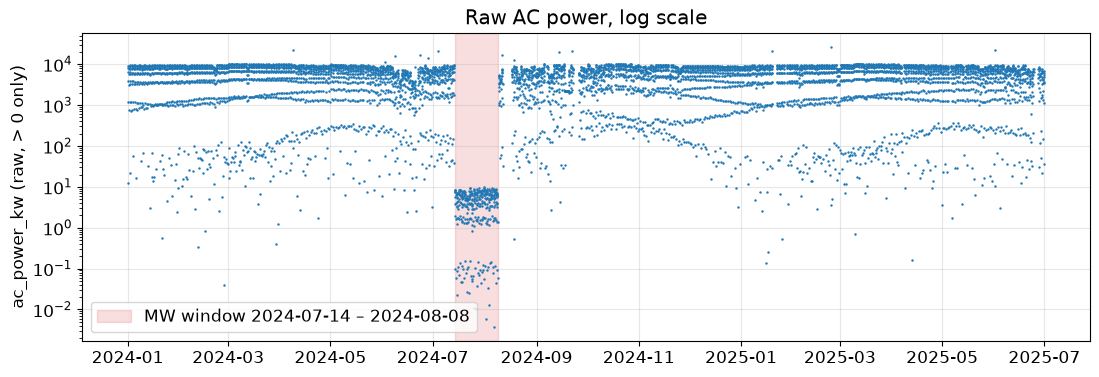

In [3]:
p = train_raw["ac_power_kw"]
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train_raw["timestamp"], p.where(p > 0), ".", ms=1.5, color="C0")
ax.axvspan(MW_START, MW_END, color="C3", alpha=0.15, label=f"MW window {MW_START:%Y-%m-%d} – {MW_END:%Y-%m-%d}")
ax.set_yscale("log")
ax.set_ylabel("ac_power_kw (raw, > 0 only)")
ax.set_title("Raw AC power, log scale")
ax.legend(loc="lower left")
plt.show()

## 3. What's known at forecast time
Only the `test.csv` columns exist for tomorrow. Measured irradiance, temperatures, rainfall and status are history-only,
so I use them for cleaning and error diagnosis but **never as model inputs** (`src/features.py` asserts this).

In [4]:
forecast_cols = [c for c in test_raw.columns if c != "timestamp"]
train_only = [c for c in train_raw.columns if c not in test_raw.columns]
print("Known for tomorrow:     ", ["timestamp"] + forecast_cols)
print("History only (no input):", train_only)
print(f"\nM2 features ({len(FEATURES)}), all derived from forecast + timestamp + plant geometry:\n{FEATURES}")

Known for tomorrow:      ['timestamp', 'forecast_cloud_cover', 'forecast_temp_c', 'forecast_wind_ms', 'forecast_humidity_pct']
History only (no input): ['measured_poa_wm2', 'measured_module_temp_c', 'measured_ambient_temp_c', 'rainfall_mm', 'status', 'ac_power_kw']

M2 features (17), all derived from forecast + timestamp + plant geometry:
['cloud', 'cloud_s1', 'cloud_s2', 'cloud_day_mean', 'temp', 'wind', 'rh', 'elevation', 'azimuth', 'cos_aoi', 'cs_poa', 'phys_poa', 'cell_temp', 'phys_power', 'hour', 'doy_sin', 'doy_cos']


## 4. Physics baseline (B2b)
Forecast → power via a physical chain (`src/solar.py`, `PhysicsModel`):
clear-sky irradiance (Ineichen, fitted monthly turbidity) → forecast cloud attenuation `1 − a·Cᵇ` → Erbs + Hay-Davies
plane-of-array irradiance → Faiman cell temperature → −0.35 %/°C → one fitted loss factor. Clipped to 10 MW, 0 at night.

In [5]:
print(inspect.getsource(PhysicsModel._unit_power))

    def _unit_power(self, geo, fc, return_tcell=False):
        """Power per unit loss_factor (before clipping) and POA."""
        cs = clearsky(geo, self.tl)
        if self.cloud_mode == "none":
            poa = cs["poa"].values
        else:
            ghi = cs["ghi"].values * cloud_factor(fc["forecast_cloud_cover"].values, *self.ab)
            poa = allsky_poa(geo, ghi)
        t_cell = pvlib.temperature.faiman(poa, fc["forecast_temp_c"].values, fc["forecast_wind_ms"].values)
        tf = 1 + TEMP_COEFF * (t_cell - 25)
        if return_tcell:
            return DC_KWP * poa / 1000 * tf, poa, cs["poa"].values, np.asarray(t_cell)
        return DC_KWP * poa / 1000 * tf, poa, cs["poa"].values



Only three things are fitted: turbidity, the cloud curve `a, b`, and the loss factor. They're nearly identical
across validation folds. Worth noting: attenuation is weak below ~0.6 cloud cover.

fold,F1,F2,F3,F4,F5,F6
physics_cloud_a,0.63,0.600,0.570,0.56,0.560,0.570
physics_cloud_b,5.30,5.000,4.400,4.40,4.300,4.400
physics_loss_factor,0.86,0.861,0.863,0.86,0.858,0.855


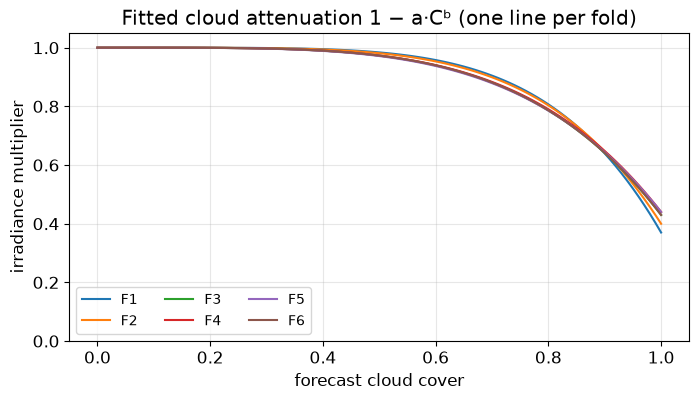

In [6]:
audit = pd.read_csv(RESULTS / "fold_audit.csv", parse_dates=["train_start", "train_end", "valid_start", "valid_end"])
display(audit.set_index("fold")[["physics_cloud_a", "physics_cloud_b", "physics_loss_factor"]].round(3).T)

c = np.linspace(0, 1, 101)
fig, ax = plt.subplots(figsize=(8, 4))
for _, r in audit.iterrows():
    ax.plot(c, cloud_factor(c, r["physics_cloud_a"], r["physics_cloud_b"]), label=r["fold"])
ax.set(xlabel="forecast cloud cover", ylabel="irradiance multiplier", ylim=(0, 1.05),
       title="Fitted cloud attenuation 1 − a·Cᵇ (one line per fold)")
ax.legend(ncol=3, fontsize=10)
plt.show()

## 5. LightGBM correction (M2)
M2 learns what the physics gets systematically wrong. Target = **actual / B2b** on daylight training hours;
prediction = B2b × predicted ratio. Hours with B2b < 200 kW just keep the physics value. Features are the section 3
list plus the B2b outputs. Production trains on the soiling-corrected target `ac_power_clean`.
Config is fixed (no tuning inside the folds):

In [7]:
print(f"LightGBM: {FIXED_LEAVES} leaves, {FIXED_ITERS} boosting rounds, 5 seeds averaged {FIXED_SEEDS}")
print(f"Ratio model applied where B2b >= {MIN_PHYS_KW:.0f} kW")

LightGBM: 15 leaves, 295 boosting rounds, 5 seeds averaged (42, 43, 44, 45, 46)
Ratio model applied where B2b >= 200 kW


## 6. Final model: 50/50 blend (BL50)
`BL50 = 0.5·B2b + 0.5·M2`, zero when the sun is below the horizon, clipped to [0, 10,000] kW. Same code as `run.py`:

In [8]:
print(inspect.getsource(run.predict_test))

def predict_test(m2, b2b, test):
    geo = geometry(test["timestamp"])
    p_b2b = b2b.predict(geo, test)
    p_m2 = m2.predict(geo, test)
    p = 0.5 * p_b2b + 0.5 * p_m2
    night = geo["elevation"].values < 0
    p[night] = 0.0
    p = np.clip(p, 0, AC_KW)
    return p, p_b2b, p_m2, geo



Validation predictions (section 7) for the clearest and cloudiest Jul–Aug 2024 day (fold F1, same season as the
test period):

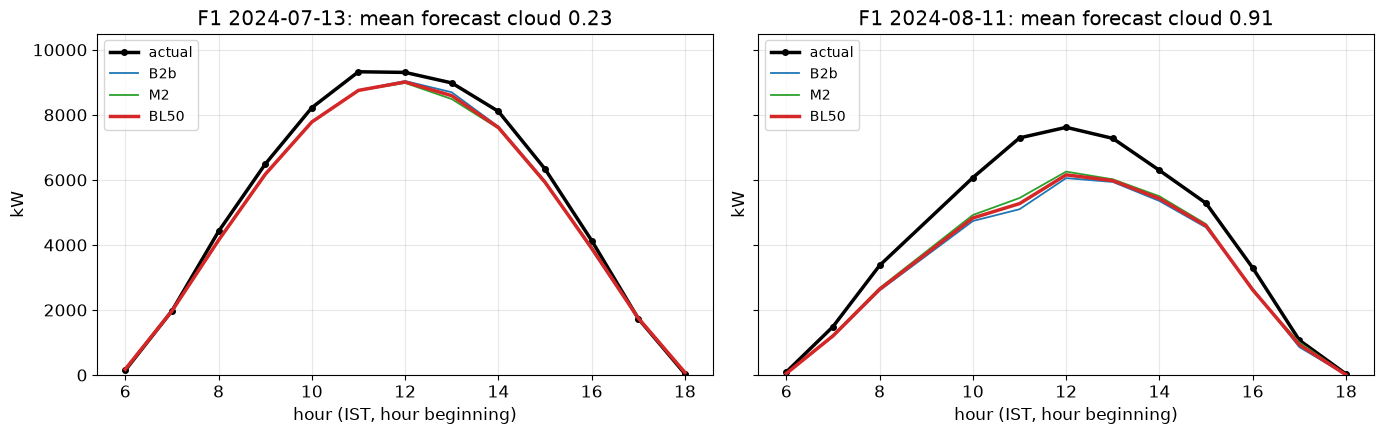

In [9]:
val = pd.read_csv(RESULTS / "validation_predictions.csv", parse_dates=["timestamp"])
fc = train_raw.drop_duplicates("timestamp").set_index("timestamp").replace([-999, 9999], np.nan)
wide = (val.pivot_table(index=["fold", "timestamp"], columns="model", values="predicted_ac_power_kw")
           .join(val.drop_duplicates(["fold", "timestamp"]).set_index(["fold", "timestamp"])
                 [["actual_ac_power_kw", "is_daylight"]])
           .reset_index()
           .join(fc[forecast_cols + ["measured_poa_wm2", "measured_module_temp_c", "status"]], on="timestamp"))
wide["date"] = wide["timestamp"].dt.normalize()
day_wide = wide[wide["is_daylight"]]

def plot_day(ax, fold, date):
    d = day_wide[(day_wide["fold"] == fold) & (day_wide["date"] == date)]
    h = d["timestamp"].dt.hour
    ax.plot(h, d["actual_ac_power_kw"], "k-o", lw=2.5, ms=4, label="actual")
    for m, col in [("B2b", "C0"), ("M2", "C2"), ("BL50", "C3")]:
        ax.plot(h, d[m], color=col, lw=2.5 if m == "BL50" else 1.3, label=m)
    ax.set(xlabel="hour (IST, hour beginning)", ylabel="kW", ylim=(0, 10_500),
           title=f"{fold} {date:%Y-%m-%d}: mean forecast cloud {d['forecast_cloud_cover'].mean():.2f}")
    ax.legend(fontsize=10, loc="upper left")

f1_days = (day_wide[day_wide["fold"] == "F1"].groupby("date")
           .agg(cloud=("forecast_cloud_cover", "mean"), hours=("BL50", "size")))
f1_days = f1_days[f1_days["hours"] >= 11].sort_values("cloud")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
plot_day(axes[0], "F1", f1_days.index[0])
plot_day(axes[1], "F1", f1_days.index[-1])
plt.tight_layout()
plt.show()

## 7. Leakage-safe validation
**My original validation had leakage, so its 3.87 % MAE is not the final number.** The problems:
- `src/clean.py` ran on the whole training file before splitting into folds, so the soiling correction (centred 7-day
  median, Jun–Oct baseline, back-fill) used data from after each validation window.
- Fold F2 trained on data *after* its validation window (`src/validate.py` labels it "optimistic").
- Forecast gaps could be filled from the next day's forecast, and scoring was against the cleaned (rescaled/soiling-corrected) target.

**Final validation** (`experiments/leakage_safe_validation.py`), six forward folds:
- Raw rows are split at the fold boundary *before* any cleaning or fitting. Turbidity, cloud curve, loss factor
  and LightGBM are fitted on training rows only. The script asserts `max(train timestamp) < min(validation timestamp)`.
- Forecast gaps are only filled within the same day. No soiling correction, since it needs future data.
- Scored against **raw** actuals. Invalid hours (STOP/PARTIAL, sentinels, spikes, the MW window) are dropped, not rewritten.
- Production config is frozen (15 leaves, 295 rounds, seeds 42–46, BL50) and just re-measured, no tuning.

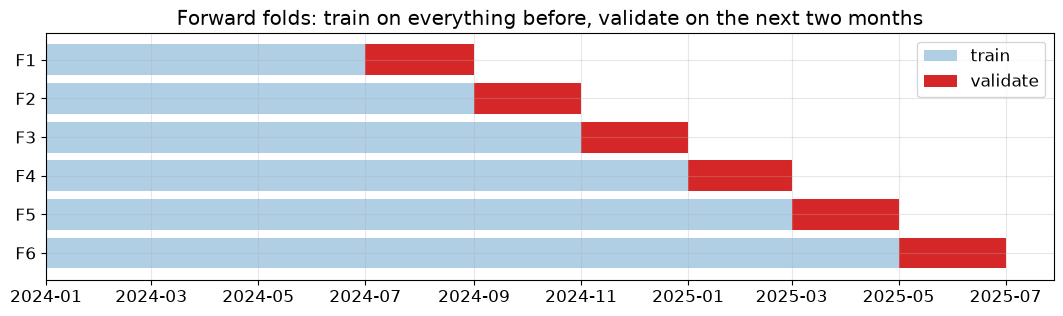

,fold,train_end,valid_start,valid_end,m2_training_rows,scored_daylight_valid_rows
0,F1,2024-06-30 23:00:00,2024-07-01,2024-08-31 23:00:00,2012,379
1,F2,2024-08-31 23:00:00,2024-09-01,2024-10-31 23:00:00,2631,595
2,F3,2024-10-31 23:00:00,2024-11-01,2024-12-31 23:00:00,3169,680
3,F4,2024-12-31 23:00:00,2025-01-01,2025-02-28 23:00:00,3768,581
4,F5,2025-02-28 23:00:00,2025-03-01,2025-04-30 23:00:00,4350,738
5,F6,2025-04-30 23:00:00,2025-05-01,2025-06-30 23:00:00,5011,723


In [10]:
assert (audit["train_end"] < audit["valid_start"]).all()

fig, ax = plt.subplots(figsize=(13, 3.2))
for i, r in audit.iterrows():
    ax.barh(r["fold"], r["train_end"] - r["train_start"], left=r["train_start"], color="C0", alpha=0.35,
            label="train" if i == 0 else None)
    ax.barh(r["fold"], r["valid_end"] - r["valid_start"], left=r["valid_start"], color="C3",
            label="validate" if i == 0 else None)
ax.invert_yaxis()
ax.set_title("Forward folds: train on everything before, validate on the next two months")
ax.legend(loc="upper right")
plt.show()

audit[["fold", "train_end", "valid_start", "valid_end", "m2_training_rows", "scored_daylight_valid_rows"]]

## 8. Metric: daylight MAE
- Night is trivially 0 and every model predicts exactly 0 there. Including it roughly halves the MAE
  without saying anything about skill.
- MAE in kW maps directly to schedule error: each kW off is energy over- or under-delivered.
  It's also less driven by a few extreme hours than RMSE (RMSE still reported).
- Normalised by the 10 MW rating, so **2.744 % = 274 kW** average hourly error.

In [11]:
summary = pd.read_csv(RESULTS / "model_summary.csv")
night = val[(val["model"] == "BL50") & ~val["is_daylight"]]
print(f"BL50 night rows: {len(night)}, all predicted 0: {(night['predicted_ac_power_kw'] == 0).all()}")
summary[summary["model"] == "BL50"].set_index("population")[["n_rows", "mae_kw", "mae_pct_capacity"]]

BL50 night rows: 3724, all predicted 0: True


,n_rows,mae_kw,mae_pct_capacity
population,,,
ALL-VALID,7420,139.240,1.392
DAYLIGHT-VALID,3696,274.433,2.744


## 9. Validation result (all six folds pooled, daylight hours)

In [12]:
res = (summary[summary["population"] == "DAYLIGHT-VALID"].set_index("model")
       [["n_rows", "mae_kw", "mae_pct_capacity", "rmse_kw", "mean_bias_kw"]].sort_values("mae_kw"))
bl50 = res.loc["BL50"]
d = val[(val["model"] == "BL50") & val["is_daylight"]]
assert np.isclose((d["predicted_ac_power_kw"] - d["actual_ac_power_kw"]).abs().mean(), bl50["mae_kw"])
print(f"BL50 pooled daylight MAE = {bl50['mae_kw']:.2f} kW = {bl50['mae_pct_capacity']:.3f} % of 10 MW "
      f"({int(bl50['n_rows'])} hours)")
res.round({"mae_kw": 2, "mae_pct_capacity": 3, "rmse_kw": 2, "mean_bias_kw": 2})

BL50 pooled daylight MAE = 274.43 kW = 2.744 % of 10 MW (3696 hours)


,n_rows,mae_kw,mae_pct_capacity,rmse_kw,mean_bias_kw
model,,,,,
BL50,3696,274.43,2.744,412.11,68.77
M2,3696,281.62,2.816,422.42,48.90
B2b,3696,287.14,2.871,430.17,88.64
B0,3696,476.19,4.762,791.62,179.57


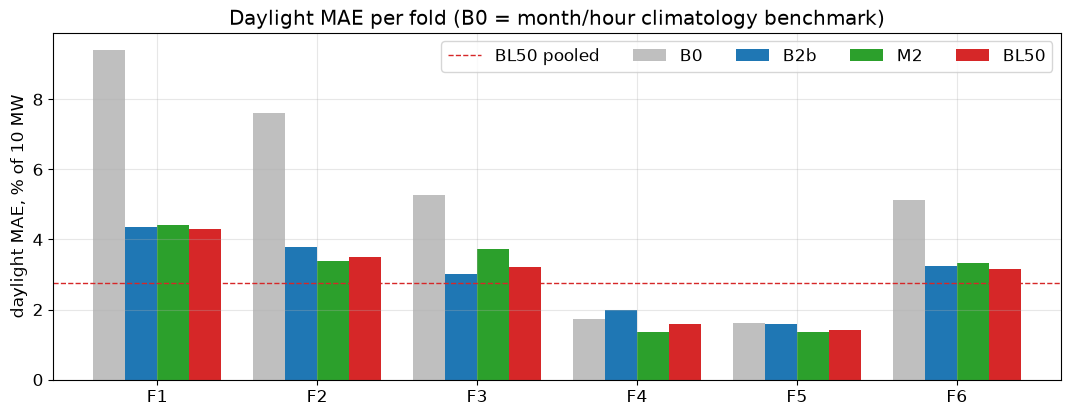

Best model per fold (excl. B0): {'F1': 'BL50', 'F2': 'M2', 'F3': 'B2b', 'F4': 'M2', 'F5': 'M2', 'F6': 'BL50'}


In [13]:
fold_res = pd.read_csv(RESULTS / "fold_results.csv")
per_fold = (fold_res[fold_res["population"] == "DAYLIGHT-VALID"]
            .pivot(index="fold", columns="model", values="mae_pct_capacity")[["B0", "B2b", "M2", "BL50"]])
ax = per_fold.plot.bar(figsize=(13, 4.5), rot=0, width=0.8, color=["0.75", "C0", "C2", "C3"])
ax.axhline(bl50["mae_pct_capacity"], color="C3", ls="--", lw=1, label="BL50 pooled")
ax.set(ylabel="daylight MAE, % of 10 MW", xlabel="",
       title="Daylight MAE per fold (B0 = month/hour climatology benchmark)")
ax.legend(ncol=5)
plt.show()
print("Best model per fold (excl. B0):", per_fold.drop(columns="B0").idxmin(axis=1).to_dict())

- BL50 has the lowest pooled error and is never the worst of the three forecast models in any fold. M2 alone wins
  more individual folds, and the blend only beats M2 by ~7 kW.
- **Caveat for the test period:** the pooled number includes the easier dry-season folds. The monsoon folds F1
  (Jul–Aug) and F2 (Sep–Oct) are at 4.3 % and 3.5 %, so expect Jul–Aug 2025 to come in worse than 2.744 %.
- BL50 and the hyperparameters were picked on the original folds, so this is an honest re-measurement of a
  frozen setup, not a fully untouched hold-out.

## 10. A poor prediction
Largest BL50 daylight errors in `validation_predictions.csv` (with forecast columns and status joined from `train.csv`):

In [14]:
day_wide = day_wide.assign(abs_err=(day_wide["BL50"] - day_wide["actual_ac_power_kw"]).abs())
day_wide.nlargest(5, "abs_err")[["timestamp", "fold", "actual_ac_power_kw", "BL50", "abs_err",
                                 "forecast_cloud_cover", "measured_poa_wm2", "status"]]

,timestamp,fold,actual_ac_power_kw,BL50,abs_err,forecast_cloud_cover,measured_poa_wm2,status
2365,2024-11-19 13:00:00,F3,5327.79,9012.058,3684.268,0.223,834.8,NaN
1123,2024-09-26 13:00:00,F2,5402.43,7851.599,2449.169,0.724,503.0,run
7306,2025-06-23 10:00:00,F6,4643.20,7026.078,2382.878,0.638,427.6,RUN
1208,2024-09-30 11:00:00,F2,6856.26,9049.424,2193.164,0.578,638.3,RUN
467,2024-08-20 12:00:00,F1,6101.47,8263.690,2162.220,0.708,NaN,RUN


The worst single hour (2024-11-19 13:00) has a missing status and PARTIAL hours around it. Probably a
plant-availability issue the validity mask missed rather than a forecast miss, so I skip it.
Instead I look at **the worst day by daylight MAE, and its worst hour**:

In [15]:
day_mae = day_wide.groupby(["fold", "date"])["abs_err"].mean()
case_fold, case_date = day_mae.idxmax()
case = day_wide[(day_wide["fold"] == case_fold) & (day_wide["date"] == case_date)].nlargest(1, "abs_err").iloc[0]
print(f"worst day: {case_fold} {case_date:%Y-%m-%d}, daylight MAE {day_mae.max():.0f} kW")
case[["timestamp", "actual_ac_power_kw", "BL50", "abs_err", "B2b", "M2", *forecast_cols]].to_frame("value")

worst day: F6 2025-06-23, daylight MAE 1143 kW


,value
timestamp,2025-06-23 10:00:00
actual_ac_power_kw,4643.2
BL50,7026.078
abs_err,2382.878
B2b,7123.182
M2,6928.974
forecast_cloud_cover,0.638
forecast_temp_c,25.8
forecast_wind_ms,5.78
forecast_humidity_pct,83.0


Diagnosis only: refit that fold's B2b physics exactly as in validation to get the forecast-implied irradiance,
then compare with what the pyranometer measured (measured values are never model inputs).

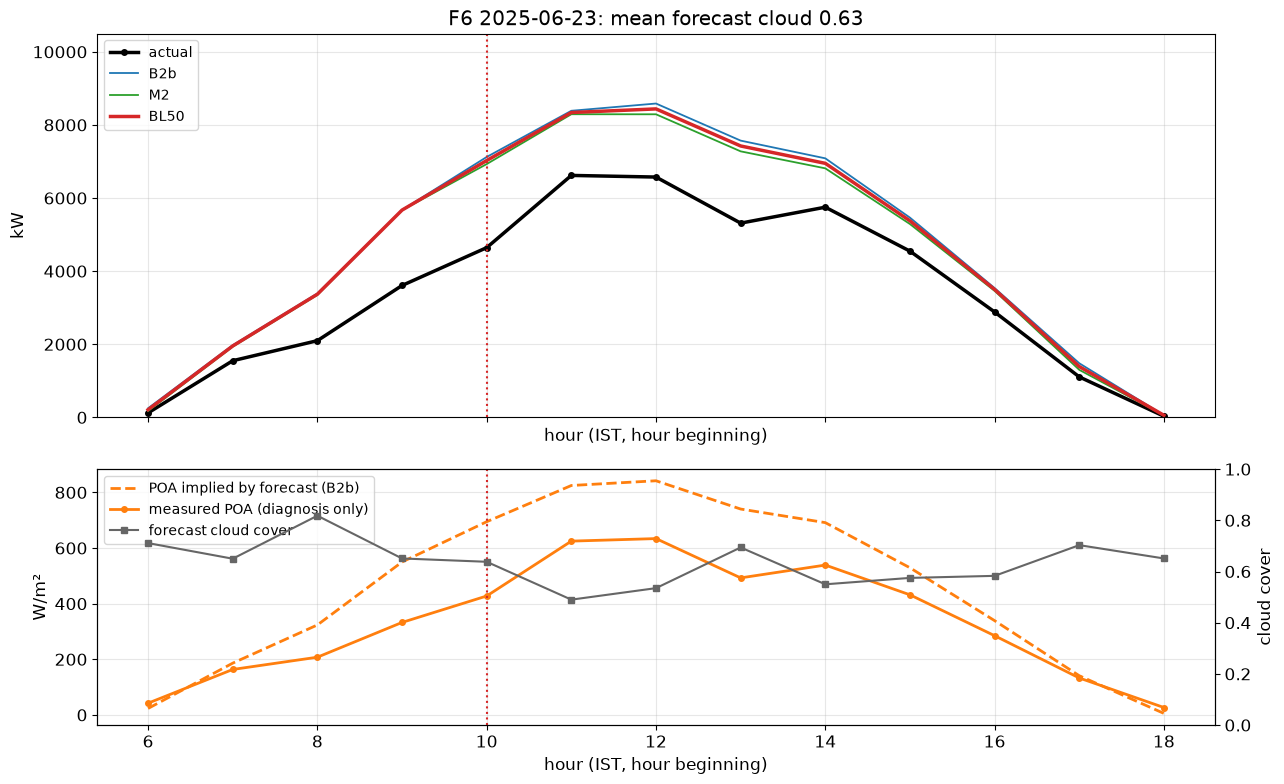

,timestamp,status,forecast_cloud_cover,forecast_poa,measured_poa_wm2,actual_vs_measured_poa
4,2025-06-23 10:00:00,RUN,0.638,694.663,427.6,1.037


In [16]:
raw_str = pd.read_csv(DATA / "train.csv", dtype={"timestamp": str, "status": str})
raw_str = raw_str.assign(ts=pd.to_datetime(raw_str["timestamp"], format="%Y-%m-%d %H:%M:%S", errors="coerce")
                         .fillna(pd.to_datetime(raw_str["timestamp"], format="%d-%m-%Y %H:%M", errors="coerce")))
fold_def = next(f for f in lsv.FOLDS if f.name == case_fold)
fold_train = lsv.clean_training_rows(raw_str[raw_str["ts"] < fold_def.train_end_exclusive].drop(columns="ts"), fold_def)
phys = lsv.FoldPhysics().fit(fold_train, geometry(fold_train["timestamp"]))

d = day_wide[(day_wide["fold"] == case_fold) & (day_wide["date"] == case_date)].reset_index(drop=True)
comp = phys.components(geometry(d["timestamp"]), d[["timestamp", *forecast_cols]])
assert np.allclose(comp["phys_power"].values, d["B2b"].values)   # identical to the saved B2b predictions
d["forecast_poa"] = comp["phys_poa"].values
d["actual_vs_measured_poa"] = d["actual_ac_power_kw"] / lsv.expected_measured_power(d)

fig, ax = plt.subplots(2, 1, figsize=(13, 8), sharex=True, gridspec_kw={"height_ratios": [3, 2]})
plot_day(ax[0], case_fold, case_date)
h = d["timestamp"].dt.hour
ax[1].plot(h, d["forecast_poa"], "C1--", lw=2, label="POA implied by forecast (B2b)")
ax[1].plot(h, d["measured_poa_wm2"], "C1-o", ms=4, lw=2, label="measured POA (diagnosis only)")
ax[1].set(ylabel="W/m²", xlabel="hour (IST, hour beginning)")
ax2 = ax[1].twinx()
ax2.plot(h, d["forecast_cloud_cover"], "-s", color="0.4", ms=4, label="forecast cloud cover")
ax2.set(ylim=(0, 1), ylabel="cloud cover")
ax2.grid(False)
h1, l1 = ax[1].get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax[1].legend(h1 + h2, l1 + l2, fontsize=10, loc="upper left")
for a in ax:
    a.axvline(case["timestamp"].hour, color="C3", ls=":", lw=1.5)
plt.tight_layout()
plt.show()

d.loc[d["timestamp"] == case["timestamp"], ["timestamp", "status", "forecast_cloud_cover", "forecast_poa",
                                          "measured_poa_wm2", "actual_vs_measured_poa"]]

**What the data shows**
- Plant ran normally: status RUN, and actual power matches what the *measured* irradiance supports
  (`actual_vs_measured_poa` ≈ 1).
- Forecast cloud was ≈ 0.5–0.8 all day. Through the fitted cloud curve (section 4) that's close to clear sky,
  so the forecast-implied irradiance was way above what actually arrived. All models over-predicted by a similar amount
  (B2b, M2 and BL50 miss together).
- So the miss is in the **weather forecast input**, not the power model. The data can't tell us *why* the day was darker
  than forecast; cloud cover alone doesn't capture cloud thickness or type. I treat this as irreducible forecast
  uncertainty for a model that only sees these four forecast variables.

## 11. Test predictions
`run.py` cleans all of `train.csv`, fits B2b + M2 on all training data, and predicts the test forecasts with BL50.
Here I run the same functions in memory (cleaning side files go to a temp folder, so nothing in the project is
written) and compare against the submitted `predictions.csv`.

In [17]:
tmp = Path(tempfile.mkdtemp())
shutil.copy(DATA / "train.csv", tmp / "train.csv")
clean.DATA = clean.REPORTS = tmp
with redirect_stdout(StringIO()):
    train_clean = clean.run_cleaning()

m2, b2b = run.fit_final(train_clean)
pred, p_b2b, p_m2, geo = run.predict_test(m2, b2b, test_raw.assign(timestamp=test_ts))

sub = pd.read_csv(ROOT / "predictions.csv", dtype={"timestamp": str})
print(f"B2b: loss factor {b2b.loss:.3f}, cloud curve a = {b2b.ab[0]:.2f}, b = {b2b.ab[1]:.2f}")
print(f"M2: {m2.n_train} training hours")
print(f"max |in-memory − predictions.csv| = {np.abs(np.round(pred, 3) - sub['predicted_ac_power_kw']).max():.3f} kW")

B2b: loss factor 0.886, cloud curve a = 0.56, b = 4.40
M2: 5688 training hours
max |in-memory − predictions.csv| = 0.000 kW


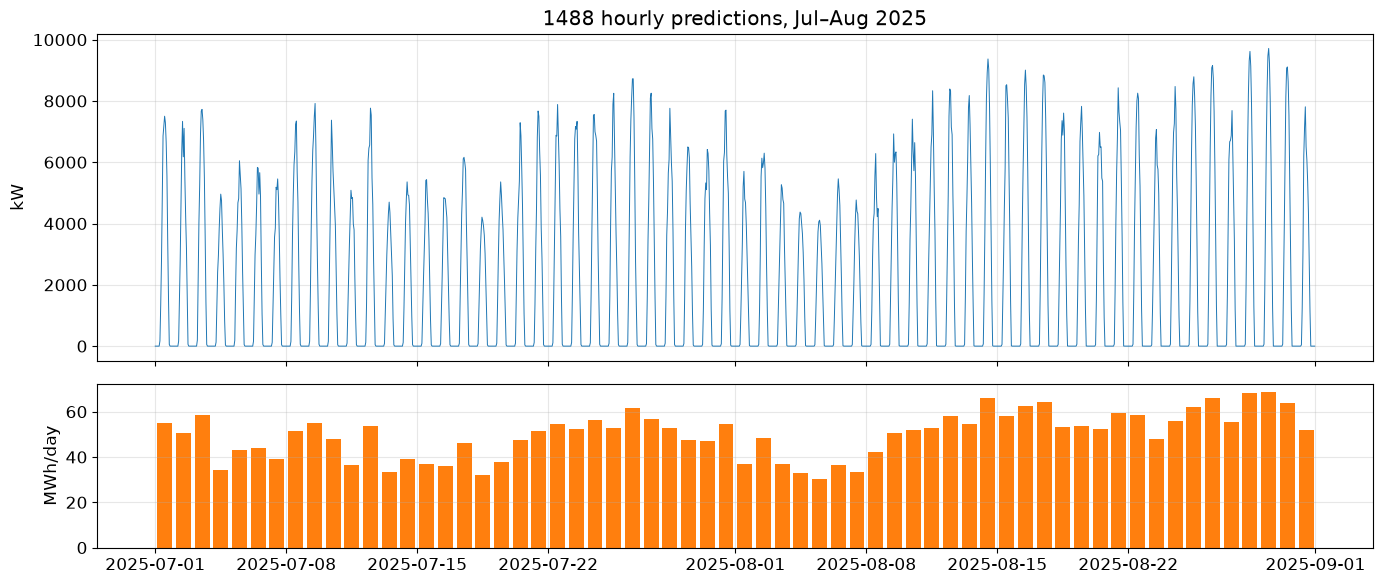

daily energy: mean 50.0, min 30.2, max 68.8 MWh


In [18]:
pred_ts = pd.to_datetime(sub["timestamp"])
daily_mwh = sub.groupby(pred_ts.dt.normalize())["predicted_ac_power_kw"].sum() / 1000
fig, ax = plt.subplots(2, 1, figsize=(14, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
ax[0].plot(pred_ts, sub["predicted_ac_power_kw"], lw=0.7)
ax[0].set_ylabel("kW"); ax[0].set_title(f"{len(sub)} hourly predictions, Jul–Aug 2025")
ax[1].bar(daily_mwh.index + pd.Timedelta(hours=12), daily_mwh.values, width=0.8, color="C1")
ax[1].set_ylabel("MWh/day")
plt.tight_layout()
plt.show()
print(f"daily energy: mean {daily_mwh.mean():.1f}, min {daily_mwh.min():.1f}, max {daily_mwh.max():.1f} MWh")

## 12. Submitted `predictions.csv`

In [19]:
run.check(sub, test_raw, geo["elevation"].values < 0)
sha = hashlib.sha256((ROOT / "predictions.csv").read_bytes()).hexdigest().upper()
readme_sha = re.search(r"\b[0-9A-F]{64}\b", (ROOT / "README.md").read_text(encoding="utf-8")).group()
print(f"SHA256 {sha}  (matches README: {sha == readme_sha})")
sub.head()

asserts ok: 1488 rows, timestamps identical and ordered, no NaN, range [0.0, 9714.0], 682 night hours all 0
SHA256 0B4D5965648CBF4A2F6F73782B119DF5519A2615113C32CDCC74A399DD8A7184  (matches README: True)


,timestamp,predicted_ac_power_kw
0,2025-07-01 00:00:00,0.0
1,2025-07-01 01:00:00,0.0
2,2025-07-01 02:00:00,0.0
3,2025-07-01 03:00:00,0.0
4,2025-07-01 04:00:00,0.0


**Summary:** BL50 = physics (B2b) + LightGBM ratio correction (M2), averaged. Leakage-safe forward validation:
**274.43 kW = 2.744 %** daylight MAE pooled over six folds (higher in the monsoon folds). Main weakness is in
section 10: when the cloud forecast is wrong, every forecast-only model is wrong with it.